# Inovegen Internship — Week 1 Assignment
## Task 1: Data Cleaning & Exploratory Data Analysis (EDA)
**Dataset:** Titanic Passenger Dataset  
**Author:** [Sehar Naeem]  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url)
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Data Inspection & Understanding
In this section, we inspect the dimensions, column types, and statistical summary of the dataset.

In [2]:
print("printing dataset dimenssion shape (rows and coloumns)",df.shape)

printing dataset dimenssion shape (rows and coloumns) (891, 12)


In [3]:
print("having a sight of full table data",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
having a sight of full table data None


In [4]:
print("the statistical information",df.describe())

the statistical information        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


## 2. Identifying Data Quality Issues
Checking for missing values, percentage of missingness, and duplicate records.

In [5]:
print("checking null values", df.isnull().sum())

checking null values PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
print("percentage for the missing values")
missing_percentage=(df.isnull().sum()/len(df))*100
print(missing_percentage[missing_percentage > 0])

percentage for the missing values
Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


In [7]:
duplicate_row=df.duplicated().sum()
print(f"duplicated rows are {duplicate_row}")

duplicated rows are 0


## 3. Data Cleaning Decisions & Implementation
- **Cabin:** Dropped because over 77% of values are missing.
- **Age:** Imputed with the median age (~28 years) to retain all 177 passenger records.
- **Embarked:** Imputed the 2 missing records with the mode ('S' - Southampton).
- **Ticket & PassengerId:** Dropped redundant identifier columns that do not contribute to behavioral analysis.


3.1 Adding missing values to age and embarked

In [8]:
print("adding missing values into age column")
df['Age']=df['Age'].fillna(df['Age'].median())

adding missing values into age column


In [9]:
print("adding missing values in embarked with most common port (mode)")
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

adding missing values in embarked with most common port (mode)


3.2 Drop 'Cabin' (too many missing values) and redundant identifier 'Ticket'

In [10]:
df=df.drop(columns=['Cabin','Ticket'])

 3.3 Confirm changes by checking missing values again

In [11]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


## Time for inspecting new shape,checking overall information of Table

In [12]:
print(df.shape)

(891, 10)


In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Fare         891 non-null    float64
 9   Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB
None


## 4. Exploratory Data Analysis (EDA) & Visualizations

### Visualization 1: Overall Passenger Survival Count
Analyzing the overall proportion of passengers who survived vs those who did not.


/tmp/ipykernel_67700/1966044784.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette=['#e74c3c', '#2ecc71'] )


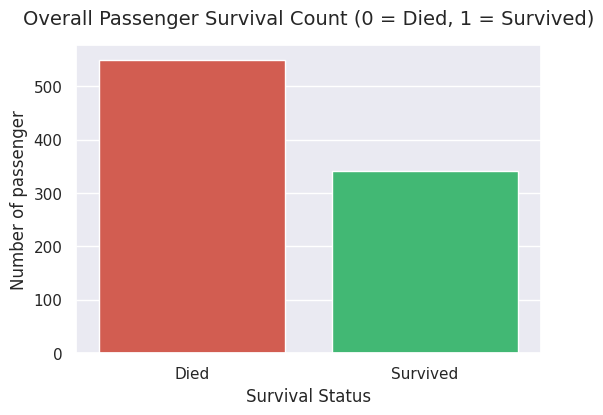

In [14]:
# Set the visual style
sns.set_theme(style="darkgrid")
plt.figure(figsize=(6,4))
# create figure
sns.countplot(x='Survived', data=df, palette=['#e74c3c', '#2ecc71'] )
#add title
plt.title('Overall Passenger Survival Count (0 = Died, 1 = Survived)', fontsize=14, pad=15)
plt.xlabel('Survival Status',fontsize='12')
plt.ylabel('Number of passenger',fontsize='12')
plt.xticks([0,1], labels=['Died','Survived'])
#show graph
plt.show()


Chart 1 insight: Over 540 people perished, while only around 340 survived (an overall survival rate of around 38%).

### Visualization 2: Survival Rate by Gender
Examining the impact of gender on the probability of survival.


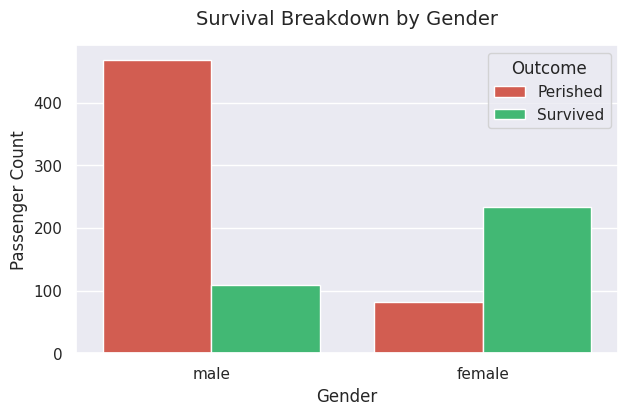

In [15]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Sex', hue='Survived', data=df, palette=['#e74c3c', '#2ecc71'])

# Add title and labels
plt.title('Survival Breakdown by Gender', fontsize=14, pad=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)
plt.legend(title='Outcome', labels=['Perished', 'Survived'])

plt.show()




Chart 2 insight: Gender was one of the strongest survival factors: over 70% of women survived, whereas over 80% of men perished.

*Interpretation:* The overall survival rate was low (~38%). However, females had a vastly higher survival count and proportion compared to males, directly reflecting the historical "women and children first" maritime evacuation protocol.


### Visualization 3: Survival by Ticket Class (Socio-economic Status)
Analyzing survival outcomes across 1st, 2nd, and 3rd passenger classes.


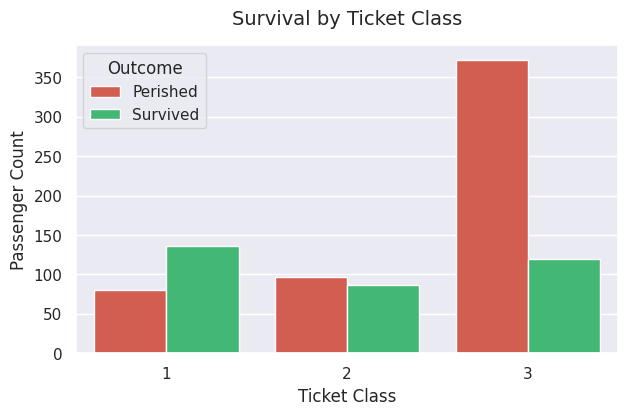

In [16]:
plt.figure(figsize=(7,4))
sns.countplot(x='Pclass',hue='Survived', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Survival by Ticket Class', fontsize=14, pad=15)
plt.xlabel('Ticket Class',fontsize='12')
plt.ylabel('Passenger Count',fontsize='12')
plt.legend(title='Outcome', labels=['Perished', 'Survived'])
plt.show()

### Visualization 4: Passenger Age Distribution by Survival
Histogram showing the age spread of passengers and their survival outcomes.


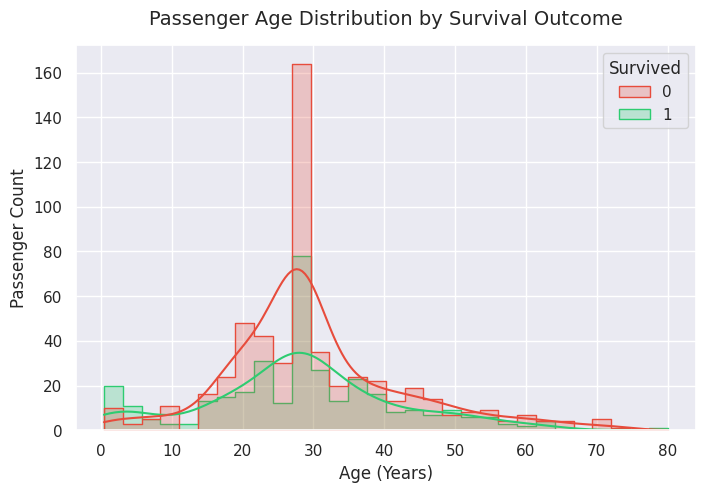

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, palette=['#e74c3c', '#2ecc71'], element="step")

plt.title('Passenger Age Distribution by Survival Outcome', fontsize=14, pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)

plt.show()


*Interpretation:*
- **Socio-economic Disparity:** Class 3 passengers suffered the highest mortality, while Class 1 passengers had the highest survival proportion (>60%).
- **Age Dynamics:** Children under 5 had higher survival rates. The cluster around 28 years reflects both the typical young-adult demographic and the median imputation of missing ages.


### Bonus Challenge: Correlation Heatmap
Analyzing linear relationships between numeric variables (Fare, Age, Pclass, SibSp, Parch, Survived).


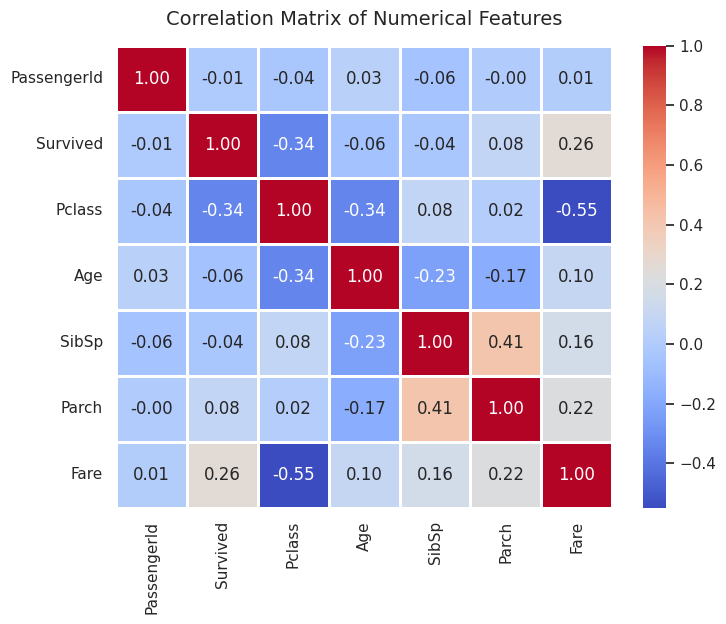

In [18]:
plt.figure(figsize=(8, 6))

# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Calculate correlation and draw heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.8)

plt.title('Correlation Matrix of Numerical Features', fontsize=14, pad=15)
plt.show()


## 5. Key Insights & Conclusions

Based on our data cleaning and exploratory data analysis of the Titanic dataset, here are 5 key insights:

1. **Gender was the Strongest Determinant of Survival:**
   - Female passengers had an overwhelming survival advantage (~74% survival rate) compared to male passengers (~19% survival rate). This provides clear data evidence of the strict enforcement of the "women and children first" maritime evacuation protocol.

2. **Socio-economic Disparity in Survival (Class Bias):**
   - Passenger class played a critical role in survival. Over 62% of 1st-class passengers survived, compared to only ~24% of 3rd-class passengers. Passengers with higher ticket fares were situated on upper decks with quicker access to lifeboats, whereas 3rd-class passengers faced physical barriers and delays.

3. **Vulnerability of Young Working-Age Adults:**
   - While infants and young children (ages 0–5) experienced higher survival rates due to rescue priority, young adults aged 18–35 represented the vast majority of casualties, particularly young male third-class passengers.

4. **Overall Low Survival Rate:**
   - Out of the 891 passengers recorded in this dataset, only 342 survived (~38.4%), while 549 perished (~61.6%), highlighting the acute shortage of lifeboats and lack of emergency preparedness.

5. **Data Quality & Integrity Impact:**
   - Over 77% of the `Cabin` data was missing, making the column unreliable for direct modeling without dropping. Conversely, `Age` was successfully imputed using the median (28 years), preserving all 891 passenger records without throwing away 20% of the dataset.
